In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

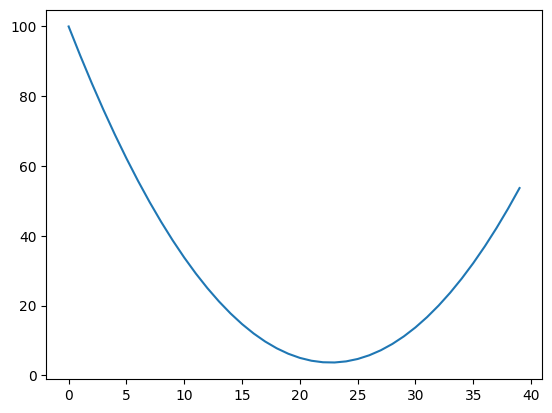

In [4]:
xs = np.arange(-5, 5, 0.25)
ys= f(xs)
plt.plot(ys)

In [5]:
h = 0.0000000000001
x=-3.0
(f(x+h) - f(x)) /h

-22.026824808563106

In [6]:
# Getting more complex

a = 2.0
b = -3.0
c = 10.0
d = a*b + c

In [7]:
d

4.0

In [8]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c

a+= h 

d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)
# differentiating with respect to a

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [9]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c

b+= h 

d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)
# differentiating with respect to b

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [10]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c

c+= h 

d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)
# differentiating with respect to b

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int and float for now"
        out = Value(self.data**other, (self,), f"**{other}")
        
        def backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
            
        out._backward = _backward
        
        return out
    
    def __truediv__(self, other):
        return self * other ** -1

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
    
    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [12]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a*b; e.label="e"
d = e + c; d.label="d"
f = Value(-2., label='f')
L = d*f; L.label='L'
L

Value(data=-8.0)

In [13]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data % .4f | grad % .4f }" % (n.label, n.data, n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            #  and connect this node to it
            dot.edge(uid+n._op, uid)
    
    for n1, n2 in edges:
        # Connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2))+n2._op)

    return dot

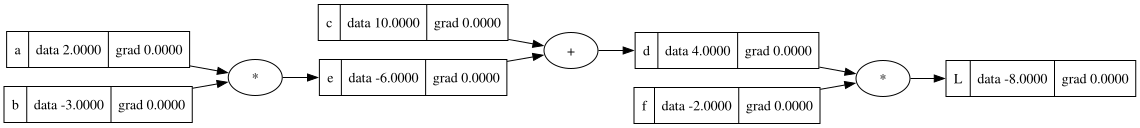

In [14]:
draw_dot(L)

At this point we have completed the forward pass. Going forward we will work on back propagation 

To compute the gradient, we compute the derivative for each node with respect to L - "derivative of L with respect to f, d..." 

a,b,c are currently just scalars, but will eventually be weights for a NN


For example, computing derivative of d using the difference quotient

$\frac{f(x+h) - f(x)}{h}$

L = d * f

$\frac{dL}{dd} = ??$

$\frac{(d+h) * f - d*f}{h}$

$\frac{d*f + h*f - d*f}{h}$

$\frac{h*f}{h} = f$

$\frac{dL}{dd} = f$

And symmetrically we know $\frac{dL}{df} = d$

Now, if we want to know the derivative of L with respect to c (dL/dC) we are trying to figure out how L changes with changes to C. Since we know the derivative of L with respect to d, if we determine the derivative of d with respect to c, we can understand its effect on L. That is, if we compute dd/dc, we can compute dL/dc

Computing dd/dc:

d = c + e

$\frac{f(x+h) - f(x)}{h}$

(c + h + e - (c + e))/h

(c + h + e - c - e )/h

h/h

 = 1.0

By symmetry 

dd/de = 1.0

# Chain Rule

If a variable z depends on a variable y which itself depends on a variable x (that is x and y are dependent variables), then z also depends on x via the intermediate variable y. In this case, the chain rule can be expressed as:

$$

\frac{dz}{dx} = \frac{dz}{dy} * \frac{dy}{dx}

$$

Stated in a different way, if we understand how changes to y impact z and changes to x impact y, we can determine how changes to x impact z

A quote by George F. Simmons: "If a car travels twice as fast as a bicycle and the bicycle is four times as fast as a walking man, then the car is 2 * 4 = 8 times as fast as the man."

Know:
dL/dd = -2
dd/dc = 1

Want:
dL/dC

Calculations:

dL/dc = dL/dd * dd/dc

= -2 * 1
= -2


When we see a + symbol in the graph, we can treat it as if it is passing back the value from the previous layer

# Calculating dL/da and dL/db

Know:
dL/de = -2

Want:
dL/da
dL/db


Calculations
dL/da = dL/de * de/da

e = a * b

(f(x+h) - f(x))/h

(((a+h) * b) - (a * b))/h
(a * b + b * h - a * b)/h
(b * h)/h
b

de/da = b = -3

dL/da = dL/de * de/da

dL/da = -2 * -3

dL/da = 6

In [15]:
def testing():
    h = 0.001
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label="e"
    d = e + c; d.label="d"
    f = Value(-2., label='f')
    L = d*f; L.label='L'
    L1 = L.data

    a = Value(2.0 , label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label="e"
    d = e + c; d.label="d"
    f = Value(-2., label='f')
    L = d*f; L.label='L'
    L2 = L.data + h
    print((L2 -L1)/h)

testing()    

1.000000000000334


In [22]:
# Inputs of the neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

# Weighted sum
x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'

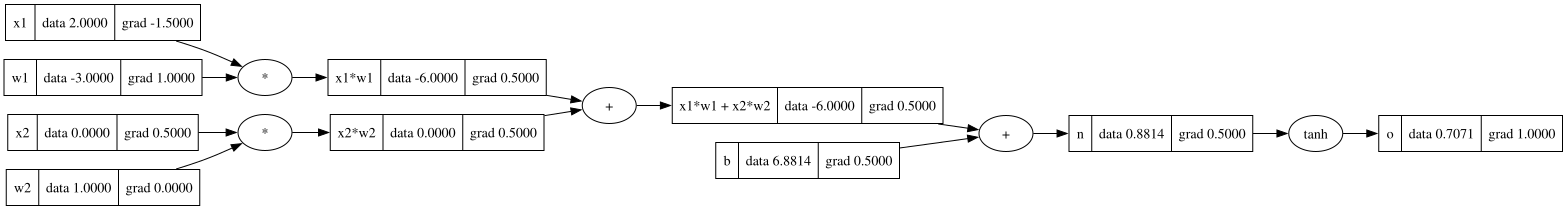

In [25]:
draw_dot(o)

In [24]:
o.backward()

In [19]:
# Calculating after implementation

o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()
w1._backward()
x1._backward()
w2._backward()
x2._backward()
# etc...

In [20]:
# Manual calculations

o.grad = 1.
n.grad = 1 - o.data**2 # This is the derivative of tanh

x1w1x2w2.grad = n.grad * 1.0
b.grad = n.grad * 1.0

x2w2.grad = x1w1x2w2.grad * 1.0
x1w1.grad = x1w1x2w2.grad * 1.0

x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data

x1.grad = x1w1.grad * w1.data
w1.grad = x1w1.grad * x1.data

In [21]:
# We need to do a topological sort on the graph to ensure that we are only calculating the gradient after the preceding values have been calculated

o.grad = 1.0

topology = []
visited = set()

def build_topology(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topology(child)
        topology.append(v)

build_topology(o)

print(topology)

for v in reversed(topology):
    v._backward()

[Value(data=2.0), Value(data=-3.0), Value(data=-6.0), Value(data=0.0), Value(data=1.0), Value(data=0.0), Value(data=-6.0), Value(data=6.881373587019543), Value(data=0.8813735870195432), Value(data=0.7071067811865476)]


In [47]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int and float for now"
        out = Value(self.data**other, (self,), f"**{other}")
        
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
            
        out._backward = _backward
        
        return out
    
    def __truediv__(self, other):
        return self * other ** -1

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward

        return out
    
    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [48]:
# Inputs of the neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

# Weighted sum
x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'
o.backward()

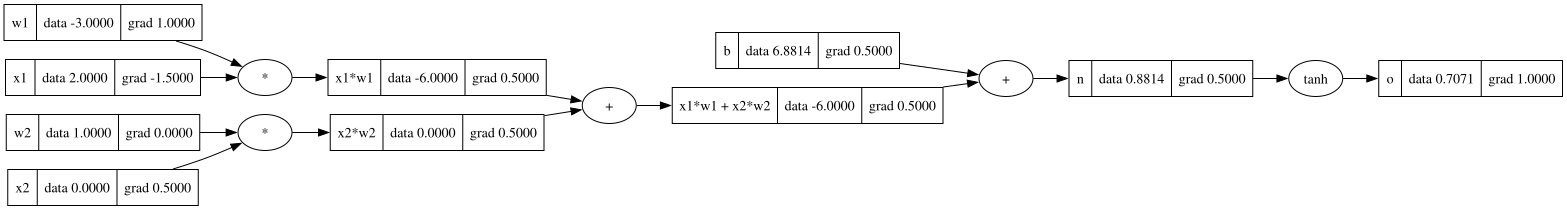

In [49]:
draw_dot(o)

In [50]:
# Inputs of the neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

# Weighted sum
x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label='n'

# o = n.tanh(); o.label='o'
# ------
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ------
o.backward()

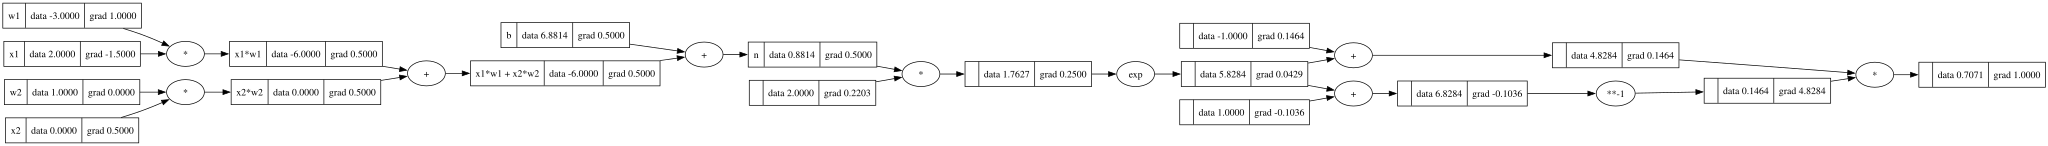

In [51]:
draw_dot(o)